✅ Dataset Loaded Successfully
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

  

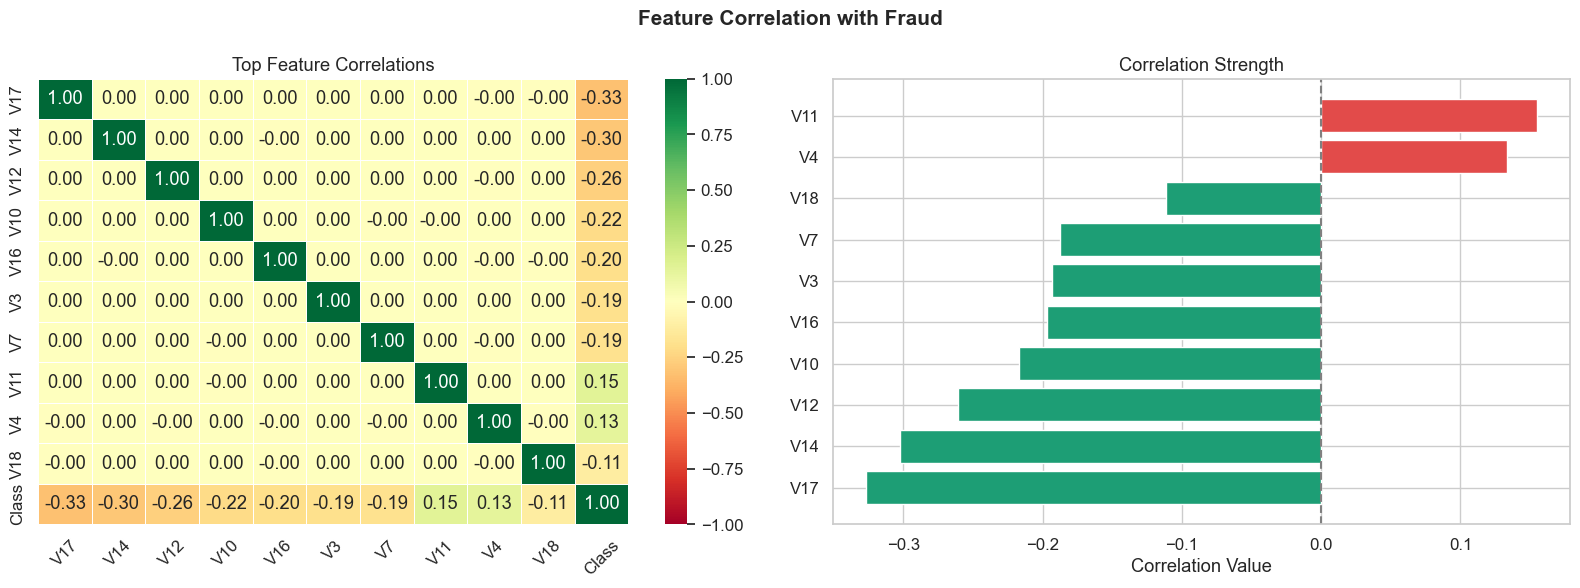

✅ Chart 4 Saved


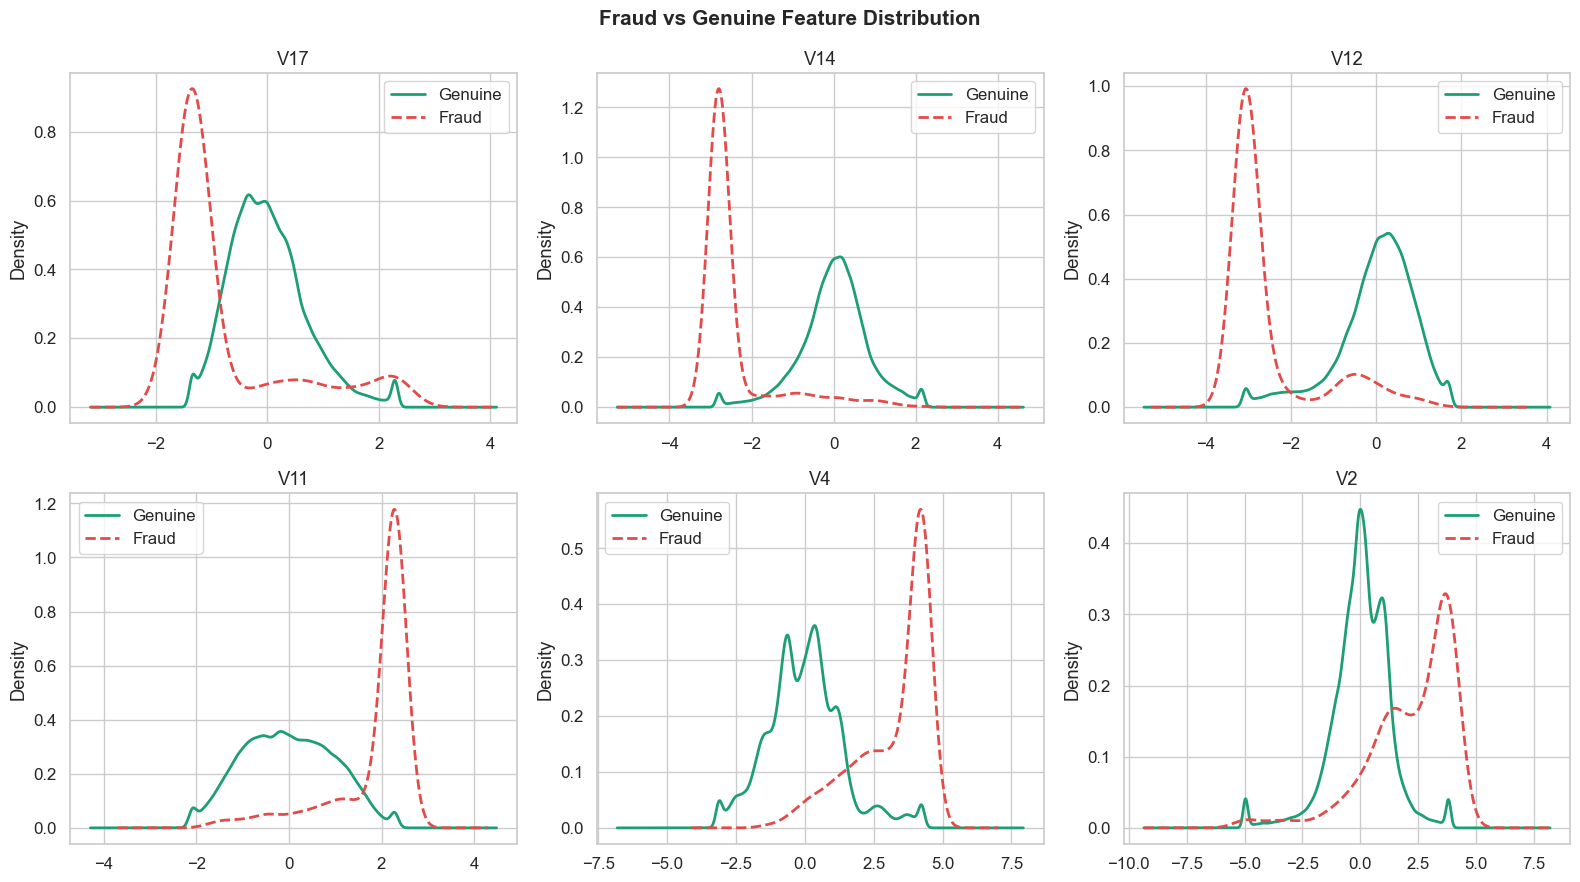

✅ Chart 5 Saved


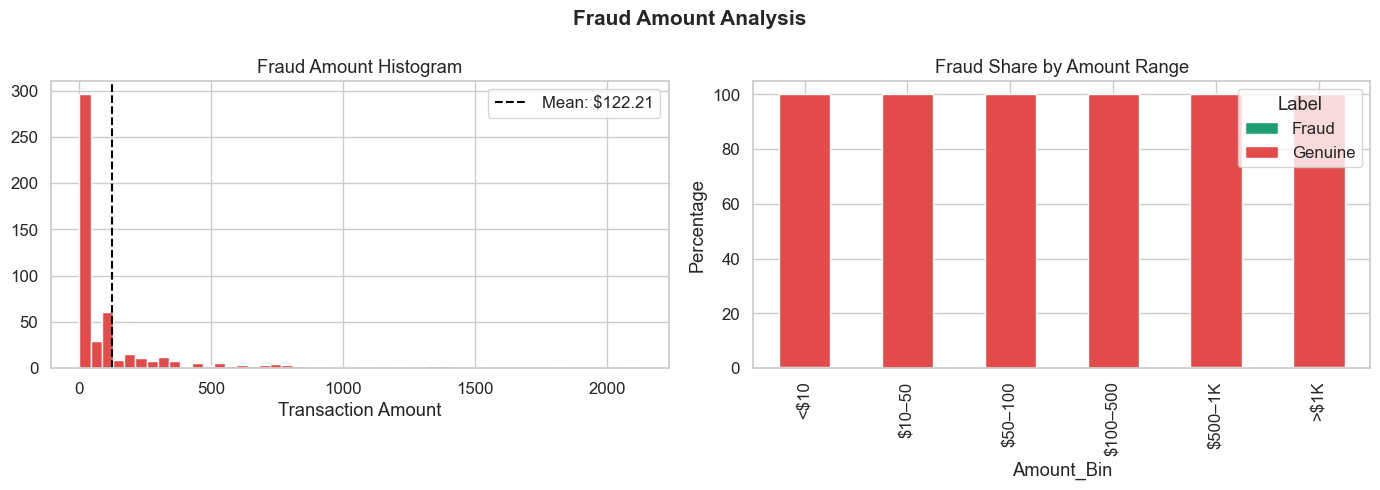

✅ Chart 6 Saved


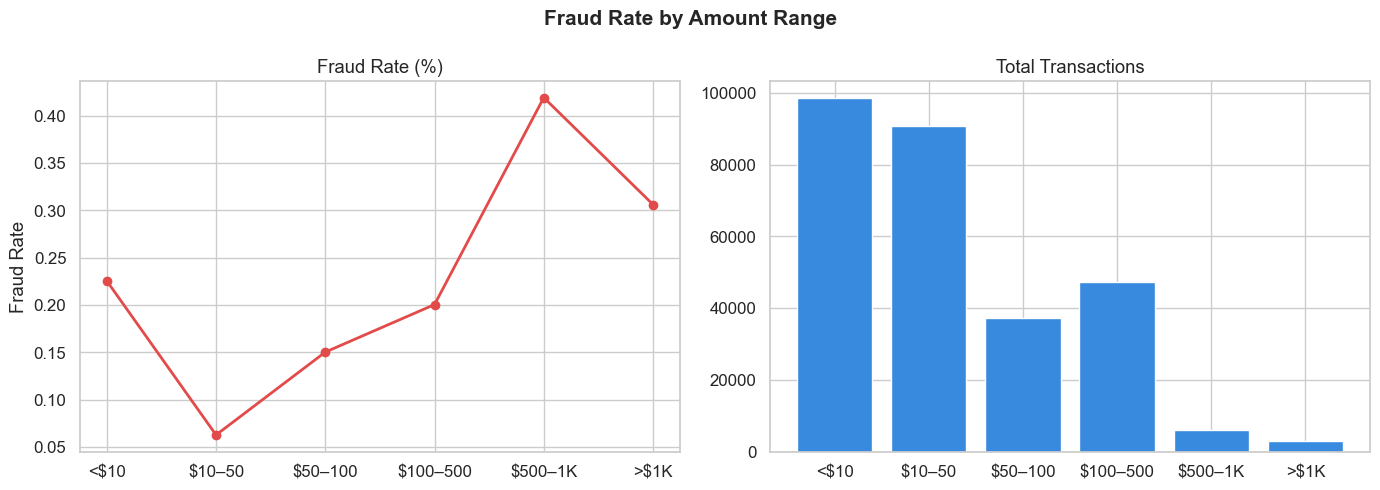

✅ Chart 7 Saved


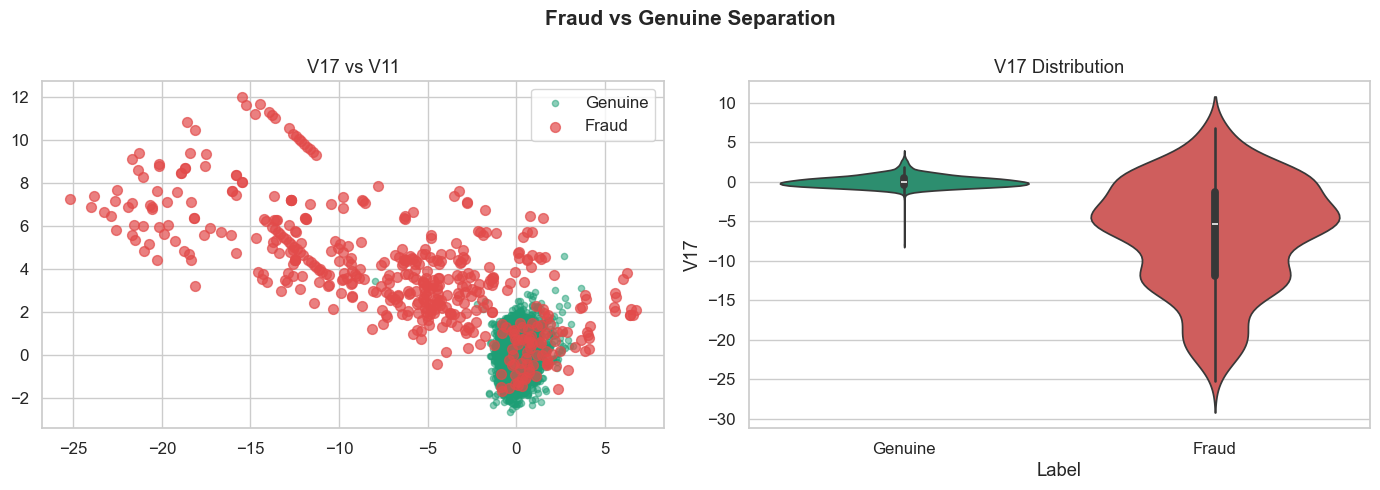

✅ Chart 8 Saved
Building Interactive Dashboard...


✅ Dashboard Saved

CREDIT CARD FRAUD ANALYSIS SUMMARY
Total Transactions : 284,807
Genuine Transactions : 284,315
Fraud Transactions : 492
Fraud Percentage : 0.1727%
Average Fraud Amount : $122.21
Peak Fraud Hour : 2:00
Top Fraud Feature : V17

✅ All charts saved inside ../images/


In [1]:
# ================================================================
#  CodeAlpha — Task 3: Data Visualization
#  Credit Card Fraud Detection Analysis
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os

# ================================================================
# SETTINGS
# ================================================================

warnings.filterwarnings('ignore')

# Create images folder
os.makedirs('../images', exist_ok=True)

# Theme
sns.set_theme(style='whitegrid', font_scale=1.1)

# Better figure size
plt.rcParams['figure.figsize'] = (10, 6)

# Colors
C_FRAUD   = '#E24B4A'
C_GENUINE = '#1D9E75'
C_NEUTRAL = '#378ADD'

# ================================================================
# LOAD DATASET
# ================================================================

df = pd.read_csv('../data/creditcard.csv')

print("✅ Dataset Loaded Successfully")
print(df.head())

# ================================================================
# FEATURE ENGINEERING
# ================================================================

df['Hour'] = (df['Time'] / 3600 % 24).astype(int)

df['Amount_Bin'] = pd.cut(
    df['Amount'],
    bins=[0, 10, 50, 100, 500, 1000, 25000],
    labels=['<$10', '$10–50', '$50–100',
            '$100–500', '$500–1K', '>$1K']
)

df['Label'] = df['Class'].map({
    0: 'Genuine',
    1: 'Fraud'
})

fraud   = df[df['Class'] == 1]
genuine = df[df['Class'] == 0]

# ================================================================
# CORRELATION PREPARATION
# ================================================================

feature_cols = [c for c in df.columns if c.startswith('V')]

correlations = df[
    feature_cols + ['Amount', 'Class']
].corr()['Class'].drop('Class')

top10 = correlations.abs().nlargest(10).index.tolist()

print("✅ Data preprocessing completed")

# ================================================================
# CHART 4 — FEATURE CORRELATION HEATMAP
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.suptitle(
    'Feature Correlation with Fraud',
    fontsize=15,
    fontweight='bold'
)

# Heatmap
corr_matrix = df[top10 + ['Class']].corr()

sns.heatmap(
    corr_matrix,
    ax=axes[0],
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

axes[0].set_title('Top Feature Correlations')
axes[0].tick_params(axis='x', rotation=45)

# Barplot
corr_vals = correlations[top10].sort_values()

bar_colors = [
    C_FRAUD if v > 0 else C_GENUINE
    for v in corr_vals.values
]

axes[1].barh(
    corr_vals.index,
    corr_vals.values,
    color=bar_colors
)

axes[1].axvline(
    0,
    color='gray',
    linestyle='--'
)

axes[1].set_title('Correlation Strength')
axes[1].set_xlabel('Correlation Value')

plt.tight_layout()

plt.savefig(
    '../images/04_feature_correlation.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Chart 4 Saved")

# ================================================================
# CHART 5 — FEATURE DISTRIBUTION KDE
# ================================================================

top_pos = correlations.nlargest(3).index.tolist()
top_neg = correlations.nsmallest(3).index.tolist()

top6 = top_neg + top_pos

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

fig.suptitle(
    'Fraud vs Genuine Feature Distribution',
    fontsize=15,
    fontweight='bold'
)

axes = axes.flatten()

for i, feat in enumerate(top6):

    lo = df[feat].quantile(0.01)
    hi = df[feat].quantile(0.99)

    genuine[feat].clip(lo, hi).plot.kde(
        ax=axes[i],
        color=C_GENUINE,
        linewidth=2,
        label='Genuine'
    )

    fraud[feat].clip(lo, hi).plot.kde(
        ax=axes[i],
        color=C_FRAUD,
        linewidth=2,
        linestyle='--',
        label='Fraud'
    )

    axes[i].set_title(feat)
    axes[i].legend()

plt.tight_layout()

plt.savefig(
    '../images/05_feature_distributions.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Chart 5 Saved")

# ================================================================
# CHART 6 — FRAUD AMOUNT ANALYSIS
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle(
    'Fraud Amount Analysis',
    fontsize=15,
    fontweight='bold'
)

# Histogram
axes[0].hist(
    fraud['Amount'],
    bins=50,
    color=C_FRAUD,
    edgecolor='white'
)

axes[0].axvline(
    fraud['Amount'].mean(),
    color='black',
    linestyle='--',
    label=f"Mean: ${fraud['Amount'].mean():.2f}"
)

axes[0].legend()

axes[0].set_title('Fraud Amount Histogram')
axes[0].set_xlabel('Transaction Amount')

# Stacked bar chart
bin_counts = df.groupby(
    ['Amount_Bin', 'Label'],
    observed=True
).size().unstack(fill_value=0)

bin_pct = (
    bin_counts.div(
        bin_counts.sum(axis=1),
        axis=0
    ) * 100
)

bin_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=[C_GENUINE, C_FRAUD]
)

axes[1].set_title('Fraud Share by Amount Range')
axes[1].set_ylabel('Percentage')

plt.tight_layout()

plt.savefig(
    '../images/06_fraud_amount_breakdown.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Chart 6 Saved")

# ================================================================
# CHART 7 — FRAUD RATE BY AMOUNT
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle(
    'Fraud Rate by Amount Range',
    fontsize=15,
    fontweight='bold'
)

fraud_rate_bin = (
    df.groupby(
        'Amount_Bin',
        observed=True
    )['Class'].mean() * 100
).reset_index()

fraud_rate_bin.columns = [
    'Amount_Bin',
    'Fraud_Rate'
]

# Line chart
axes[0].plot(
    fraud_rate_bin['Amount_Bin'].astype(str),
    fraud_rate_bin['Fraud_Rate'],
    marker='o',
    color=C_FRAUD,
    linewidth=2
)

axes[0].set_title('Fraud Rate (%)')
axes[0].set_ylabel('Fraud Rate')

# Bar chart
bin_total = df.groupby(
    'Amount_Bin',
    observed=True
).size().reset_index()

bin_total.columns = [
    'Amount_Bin',
    'Count'
]

axes[1].bar(
    bin_total['Amount_Bin'].astype(str),
    bin_total['Count'],
    color=C_NEUTRAL
)

axes[1].set_title('Total Transactions')

plt.tight_layout()

plt.savefig(
    '../images/07_fraud_rate_by_amount.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Chart 7 Saved")

# ================================================================
# CHART 8 — SCATTER + VIOLIN PLOT
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle(
    'Fraud vs Genuine Separation',
    fontsize=15,
    fontweight='bold'
)

sample_gen = genuine.sample(
    2000,
    random_state=42
)

sample_fraud = fraud.copy()

feat_x = correlations.nsmallest(1).index[0]
feat_y = correlations.nlargest(1).index[0]

# Scatter plot
axes[0].scatter(
    sample_gen[feat_x],
    sample_gen[feat_y],
    c=C_GENUINE,
    alpha=0.5,
    s=20,
    label='Genuine'
)

axes[0].scatter(
    sample_fraud[feat_x],
    sample_fraud[feat_y],
    c=C_FRAUD,
    alpha=0.7,
    s=50,
    label='Fraud'
)

axes[0].legend()

axes[0].set_title(
    f'{feat_x} vs {feat_y}'
)

# Violin plot
best_feat = correlations.abs().idxmax()

plot_df = pd.concat([
    sample_gen[[best_feat, 'Label']],
    sample_fraud[[best_feat, 'Label']]
])

sns.violinplot(
    data=plot_df,
    x='Label',
    y=best_feat,
    palette={
        'Genuine': C_GENUINE,
        'Fraud': C_FRAUD
    },
    ax=axes[1]
)

axes[1].set_title(
    f'{best_feat} Distribution'
)

plt.tight_layout()

plt.savefig(
    '../images/08_scatter_separation.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Chart 8 Saved")

# ================================================================
# CHART 9 — INTERACTIVE DASHBOARD
# ================================================================

print("Building Interactive Dashboard...")

fig_dash = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        'Class Distribution',
        'Fraud Rate by Hour',
        'Feature Correlation',
        'Fraud Rate by Amount'
    ),
    specs=[
        [{'type': 'pie'}, {'type': 'bar'}],
        [{'type': 'bar'}, {'type': 'scatter'}]
    ]
)

# Pie chart
counts = df['Class'].value_counts()

fig_dash.add_trace(
    go.Pie(
        labels=['Genuine', 'Fraud'],
        values=counts.values,
        marker_colors=[C_GENUINE, C_FRAUD]
    ),
    row=1,
    col=1
)

# Fraud by hour
fraud_by_hour = fraud.groupby('Hour').size()

fig_dash.add_trace(
    go.Bar(
        x=fraud_by_hour.index,
        y=fraud_by_hour.values,
        marker_color=C_FRAUD
    ),
    row=1,
    col=2
)

# Correlation bar
corr_top = correlations[top10].sort_values()

fig_dash.add_trace(
    go.Bar(
        x=corr_top.values,
        y=corr_top.index,
        orientation='h'
    ),
    row=2,
    col=1
)

# Fraud rate line
fig_dash.add_trace(
    go.Scatter(
        x=fraud_rate_bin['Amount_Bin'].astype(str),
        y=fraud_rate_bin['Fraud_Rate'],
        mode='lines+markers'
    ),
    row=2,
    col=2
)

fig_dash.update_layout(
    title='Credit Card Fraud Dashboard',
    height=700,
    template='plotly_white'
)

fig_dash.write_html(
    '../images/09_interactive_dashboard.html'
)

fig_dash.show()

print("✅ Dashboard Saved")

# ================================================================
# SUMMARY
# ================================================================

print("\n" + "=" * 60)

print("CREDIT CARD FRAUD ANALYSIS SUMMARY")

print("=" * 60)

print(f"Total Transactions : {len(df):,}")

print(f"Genuine Transactions : {len(genuine):,}")

print(f"Fraud Transactions : {len(fraud):,}")

print(f"Fraud Percentage : {(len(fraud)/len(df))*100:.4f}%")

print(f"Average Fraud Amount : ${fraud['Amount'].mean():.2f}")

print(f"Peak Fraud Hour : {fraud.groupby('Hour').size().idxmax()}:00")

print(f"Top Fraud Feature : {correlations.abs().idxmax()}")

print("\n✅ All charts saved inside ../images/")

print("=" * 60)